In [5]:
import numpy as np
import plotly.graph_objects as go

# Load and visualize peptide 3D coordinates
coords = np.array([[float(line.split()[i]) for i in [-3,-2,-1]] 
                   for line in open('/home/go73dov/CoarsePep3D/data/synthetic_peptides/nanotubes/nanotube_002.gro').readlines()[2:-1]])
go.Figure(go.Scatter3d(x=coords[:,0], y=coords[:,1], z=coords[:,2], 
                       mode='markers', marker=dict(size=2))).show()

In [10]:
import numpy as np
import plotly.graph_objects as go

# Load and visualize peptide 3D coordinates
coords = np.array([[float(line.split()[i]) for i in [-3,-2,-1]] 
                   for line in open('/home/go73dov/CoarsePep3D/data/peptides/fibers/run_1/PVWRADSWHC/last_five_frames/frame_000397.gro').readlines()[2:-1]])
go.Figure(go.Scatter3d(x=coords[:,0], y=coords[:,1], z=coords[:,2], 
                       mode='markers', marker=dict(size=2))).show()

In [8]:
# Loop through all peptides in run_1 and plot frame_000397
import os
from pathlib import Path

run1_path = Path('/home/go73dov/CoarsePep3D/data/peptides/fibers/run_1')
for peptide in sorted(run1_path.iterdir()):
    frame_file = peptide / 'last_five_frames' / 'frame_000397.gro'
    if frame_file.exists():
        coords = np.array([[float(line.split()[i]) for i in [-3,-2,-1]] 
                          for line in open(frame_file).readlines()[2:-1]])
        go.Figure(go.Scatter3d(x=coords[:,0], y=coords[:,1], z=coords[:,2], 
                              mode='markers', marker=dict(size=2)),
                 layout=dict(title=peptide.name)).show()

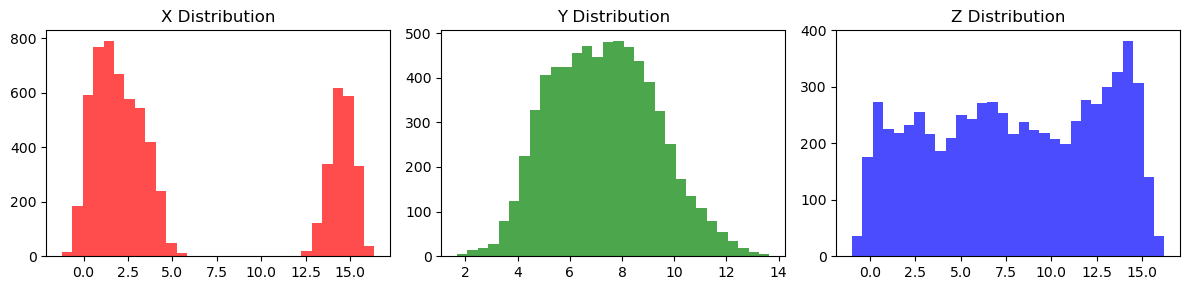

In [2]:
# Plot coordinate distributions
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
axes[0].hist(coords[:,0], bins=30, alpha=0.7, color='red')
axes[0].set_title('X Distribution')
axes[1].hist(coords[:,1], bins=30, alpha=0.7, color='green') 
axes[1].set_title('Y Distribution')
axes[2].hist(coords[:,2], bins=30, alpha=0.7, color='blue')
axes[2].set_title('Z Distribution')
plt.tight_layout()
plt.show()

In [3]:
# Function to analyze axis distributions for two extreme peaks
def analyze_axis_extremes(coords, axis_names=['X', 'Y', 'Z']):
    """
    Analyze which axis has two well-separated peaks with minimal overlap
    """
    results = {}
    
    for i, axis in enumerate(axis_names):
        data = coords[:, i]
        
        # Find histogram peaks
        hist, bins = np.histogram(data, bins=30)
        bin_centers = (bins[:-1] + bins[1:]) / 2
        
        # Find all peaks above threshold
        peaks = []
        peak_heights = []
        for j in range(1, len(hist)-1):
            if hist[j] > hist[j-1] and hist[j] > hist[j+1] and hist[j] > hist.max()*0.15:
                peaks.append(bin_centers[j])
                peak_heights.append(hist[j])
        
        # Focus on two highest peaks only
        if len(peaks) >= 2:
            # Sort by height and take top 2
            sorted_peaks = sorted(zip(peaks, peak_heights), key=lambda x: x[1], reverse=True)
            peak1, peak2 = sorted_peaks[0][0], sorted_peaks[1][0]
            height1, height2 = sorted_peaks[0][1], sorted_peaks[1][1]
            
            # Calculate separation metrics
            separation = abs(peak2 - peak1)
            mid_point = (peak1 + peak2) / 2
            
            # Find minimum between peaks (valley depth)
            valley_idx = np.argmin(np.abs(bin_centers - mid_point))
            valley_height = hist[valley_idx]
            min_peak_height = min(height1, height2)
            
            # Valley depth ratio (how deep the valley is relative to peaks)
            valley_depth = (min_peak_height - valley_height) / min_peak_height if min_peak_height > 0 else 0
            
            # Separation quality score
            std = data.std()
            separation_score = (separation / std) * valley_depth if std > 0 else 0
            
            results[axis] = {
                'has_two_peaks': True,
                'peak1': peak1,
                'peak2': peak2,
                'separation': separation,
                'valley_depth': valley_depth,
                'separation_score': separation_score
            }
            
            print(f"{axis}-axis: Peaks at {peak1:.3f} and {peak2:.3f}")
            print(f"  Separation: {separation:.3f}, Valley depth: {valley_depth:.3f}, Score: {separation_score:.3f}")
        else:
            results[axis] = {
                'has_two_peaks': False,
                'separation_score': 0
            }
            print(f"{axis}-axis: Less than 2 distinct peaks found")
    
    # Find axis with best two-peak separation
    valid_axes = {k: v for k, v in results.items() if v['has_two_peaks']}
    if valid_axes:
        best_axis = max(valid_axes.keys(), key=lambda k: results[k]['separation_score'])
        print(f"\nBest two-peak separation: {best_axis}")
    else:
        best_axis = None
        print(f"\nNo axis has clear two-peak structure")
    
    return results, best_axis

# Analyze the current coordinates
extremes, best_axis = analyze_axis_extremes(coords)

X-axis: Peaks at 1.421 and 14.303
  Separation: 12.882, Valley depth: 1.000, Score: 2.197
Y-axis: Peaks at 7.860 and 6.664
  Separation: 1.196, Valley depth: -0.019, Score: -0.011
Z-axis: Peaks at 14.229 and 11.931
  Separation: 2.298, Valley depth: -0.079, Score: -0.039

Best two-peak separation: X


X-axis: Peaks at 1.421 and 14.303
  Separation: 12.882, Valley depth: 1.000, Score: 2.197
Y-axis: Peaks at 7.860 and 6.664
  Separation: 1.196, Valley depth: -0.019, Score: -0.011
Z-axis: Peaks at 14.229 and 11.931
  Separation: 2.298, Valley depth: -0.079, Score: -0.039

Best two-peak separation: X


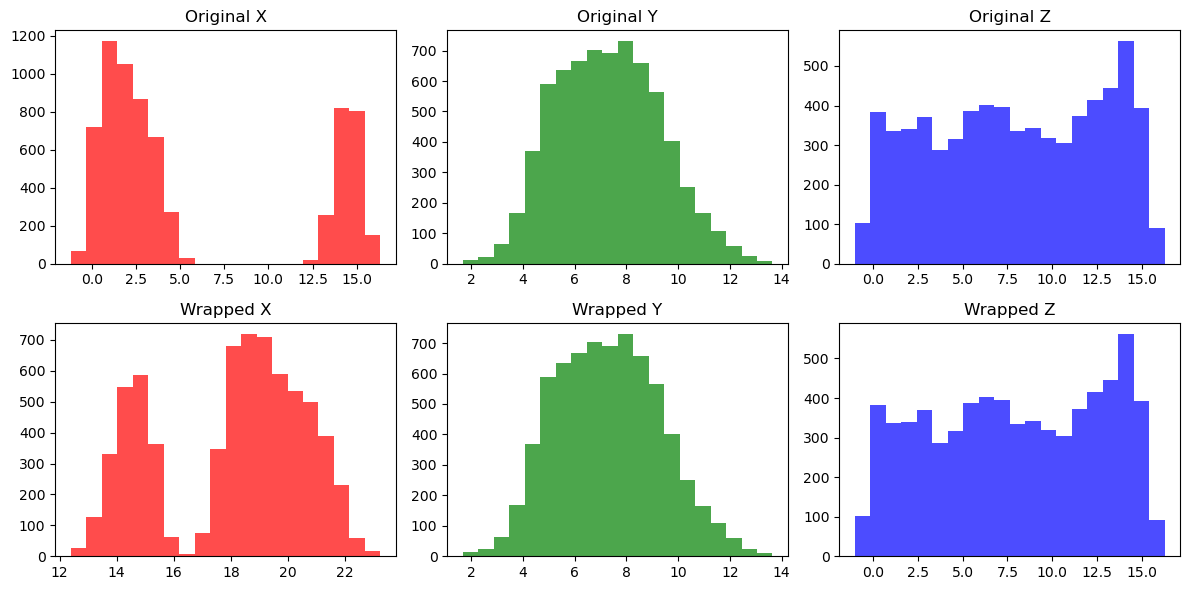

✅ Wrapped X-axis - window-based cluster detection


In [19]:
# Compact periodic boundary wrapping - window-based cluster detection
def wrap_periodic_boundary(coords, best_axis, axis_names=['X', 'Y', 'Z'], window_size=1):
    if best_axis is None: return coords
    axis_idx = axis_names.index(best_axis)
    data = coords[:, axis_idx]
    hist, bins = np.histogram(data, bins=30)
    centers = (bins[:-1] + bins[1:]) / 2
    
    # Find empty windows to detect cluster boundaries
    empty_windows = []
    for i in range(len(hist) - window_size + 1):
        window = hist[i:i + window_size]
        if np.sum(window) == 0:  # Empty window
            empty_windows.append((i, i + window_size - 1))
    
    if len(empty_windows) == 0: return coords  # No clear separation
    
    # Find the largest empty gap (most significant boundary)
    gap_sizes = [(end - start, start, end) for start, end in empty_windows]
    largest_gap = max(gap_sizes, key=lambda x: x[0])
    _, gap_start, gap_end = largest_gap
    
    # Determine left and right clusters based on the gap
    gap_center = centers[(gap_start + gap_end) // 2]
    left_mask = data < gap_center
    
    if np.sum(left_mask) == 0 or np.sum(~left_mask) == 0: return coords
    
    coords_wrapped = coords.copy()
    
    # Move left cluster so its leftmost point aligns with right cluster's rightmost point
    left_leftmost = data[left_mask].min()
    right_rightmost = data[~left_mask].max()
    shift_amount = right_rightmost - left_leftmost
    coords_wrapped[left_mask, axis_idx] += shift_amount
    
    return coords_wrapped

# Apply wrapping with fallback
extremes, best_axis = analyze_axis_extremes(coords) if 'analyze_axis_extremes' in locals() else ({}, None)
if not best_axis:
    gaps = [(i, coords[:, i].max() - coords[:, i].min()) for i in range(3)]
    best_axis = ['X', 'Y', 'Z'][max(gaps, key=lambda x: x[1])[0]]

coords_wrapped = wrap_periodic_boundary(coords, best_axis)

# Quick comparison plot
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
for i, (title, data) in enumerate([('Original', coords), ('Wrapped', coords_wrapped)]):
    for j in range(3):
        axes[i,j].hist(data[:,j], bins=20, alpha=0.7, color=['red','green','blue'][j])
        axes[i,j].set_title(f'{title} {["X","Y","Z"][j]}')
plt.tight_layout()
plt.show()
print(f"✅ Wrapped {best_axis}-axis - window-based cluster detection")

In [21]:
# 3D Plotly visualization of original vs wrapped coordinates
import plotly.graph_objects as go
from plotly.subplots import make_subplots

if 'coords_wrapped' in locals() and wrapped_axis:
    # Create side-by-side 3D plots
    fig = make_subplots(
        rows=1, cols=2,
        specs=[[{'type': 'scatter3d'}, {'type': 'scatter3d'}]],
        subplot_titles=['Original Point Cloud (Split)', f'Wrapped Point Cloud ({wrapped_axis}-axis reconnected)']
    )
    
    # Original coordinates - color by the axis that was wrapped to show the split
    axis_idx = ['X', 'Y', 'Z'].index(wrapped_axis)
    fig.add_trace(go.Scatter3d(
        x=coords[:, 0], y=coords[:, 1], z=coords[:, 2],
        mode='markers',
        marker=dict(size=3, color=coords[:, axis_idx], colorscale='Viridis', opacity=0.8),
        name='Original (Split)'
    ), row=1, col=1)
    
    # Wrapped coordinates - color by the same axis to show reconnection
    fig.add_trace(go.Scatter3d(
        x=coords_wrapped[:, 0], y=coords_wrapped[:, 1], z=coords_wrapped[:, 2],
        mode='markers', 
        marker=dict(size=3, color=coords_wrapped[:, axis_idx], colorscale='Plasma', opacity=0.8),
        name='Wrapped (Connected)'
    ), row=1, col=2)
    
    # Update layout
    fig.update_layout(
        title=f'Periodic Boundary Wrapping: Reconnecting {wrapped_axis}-axis clusters',
        scene=dict(
            xaxis_title='X', yaxis_title='Y', zaxis_title='Z',
            aspectmode='cube'
        ),
        scene2=dict(
            xaxis_title='X', yaxis_title='Y', zaxis_title='Z',
            aspectmode='cube'
        ),
        width=1200, height=600,
        showlegend=False
    )
    
    fig.show()
    
    print(f"🎯 3D visualization complete!")
    print(f"Left: Original (peptide chain split across boundary)")
    print(f"Right: Wrapped (leftmost cluster moved to connect with rightmost)")
    
    # Show connection statistics
    axis_idx = ['X', 'Y', 'Z'].index(wrapped_axis)
    original_range = coords[:, axis_idx].max() - coords[:, axis_idx].min()
    wrapped_range = coords_wrapped[:, axis_idx].max() - coords_wrapped[:, axis_idx].min()
    print(f"\n📏 {wrapped_axis}-axis statistics:")
    print(f"Original range: {original_range:.3f}")
    print(f"Wrapped range: {wrapped_range:.3f}")
    print(f"Range change: {wrapped_range - original_range:.3f}")
    
else:
    print("❌ Cannot create 3D visualization - no wrapped coordinates available")

🎯 3D visualization complete!
Left: Original (peptide chain split across boundary)
Right: Wrapped (leftmost cluster moved to connect with rightmost)

📏 X-axis statistics:
Original range: 17.566
Wrapped range: 10.839
Range change: -6.727


In [2]:
# import torch
# import torch.nn as nn
# import torch.optim as optim
# from torch.utils.data import Dataset, DataLoader
# import glob

# # Data loader
# class PeptideDataset(Dataset):
#     def __init__(self):
#         self.files = glob.glob('data/*.gro')
#         self.data = [torch.tensor([[float(line.split()[i]) for i in [-3,-2,-1]] 
#                                   for line in open(f).readlines()[2:-1]]).flatten() for f in self.files]
#     def __len__(self): return len(self.data)
#     def __getitem__(self, i): return self.data[i]

# # VAE model
# class VAE(nn.Module):
#     def __init__(self, input_dim, latent_dim=10):
#         super().__init__()
#         self.encoder = nn.Sequential(nn.Linear(input_dim, 128), nn.ReLU(), nn.Linear(128, latent_dim*2))
#         self.decoder = nn.Sequential(nn.Linear(latent_dim, 128), nn.ReLU(), nn.Linear(128, input_dim))
#     def encode(self, x):
#         h = self.encoder(x)
#         mu, logvar = h.chunk(2, dim=1)
#         return mu, logvar
#     def decode(self, z): return self.decoder(z)
#     def forward(self, x):
#         mu, logvar = self.encode(x)
#         z = mu + torch.exp(0.5*logvar) * torch.randn_like(logvar)
#         return self.decode(z), mu, logvar

# # Training
# dataset = PeptideDataset()
# loader = DataLoader(dataset, batch_size=4, shuffle=True)
# model = VAE(dataset[0].shape[0])
# optimizer = optim.Adam(model.parameters(), lr=1e-3)

# for epoch in range(50):
#     loss_sum = 0
#     for x in loader:
#         x_recon, mu, logvar = model(x)
#         recon_loss = nn.MSELoss()(x_recon, x)
#         kl_loss = -0.5 * torch.mean(torch.sum(1 + logvar - mu**2 - logvar.exp(), dim=1))
#         loss = recon_loss + 0.001 * kl_loss
#         optimizer.zero_grad()
#         loss.backward()
#         torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # Clip gradients
#         optimizer.step()
#         loss_sum += loss.item()
#     if epoch % 10 == 0: print(f'Epoch {epoch}, Loss: {loss_sum/len(loader):.4f}')

# print("Training complete!")

In [3]:
# Simplified PointNet++ VAE for ShapeNet Training
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import os
import time
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader

# PointNet++ Encoder & FC Decoder Implementation

def knn(x, k):
    """Find k-nearest neighbors"""
    inner = -2*torch.matmul(x.transpose(2, 1), x)
    xx = torch.sum(x**2, dim=1, keepdim=True)
    pairwise_distance = -xx - inner - xx.transpose(2, 1)
    idx = pairwise_distance.topk(k=k, dim=-1)[1]   # (batch_size, num_points, k)
    return idx

def get_graph_feature(x, k=20, idx=None):
    """Build graph features for EdgeConv"""
    batch_size = x.size(0)
    num_points = x.size(2)
    x = x.view(batch_size, -1, num_points)
    if idx is None:
        idx = knn(x, k=k)   # (batch_size, num_points, k)
    device = torch.device('cuda')

    idx_base = torch.arange(0, batch_size, device=device).view(-1, 1, 1)*num_points
    idx = idx + idx_base
    idx = idx.view(-1)
 
    _, num_dims, _ = x.size()
    x = x.transpose(2, 1).contiguous()   # (batch_size, num_points, num_dims)
    feature = x.view(batch_size*num_points, -1)[idx, :]
    feature = feature.view(batch_size, num_points, k, num_dims) 
    x = x.view(batch_size, num_points, 1, num_dims).repeat(1, 1, k, 1)
    
    feature = torch.cat((feature-x, x), dim=3).permute(0, 3, 1, 2).contiguous()
    return feature

class PointNetPlusPlusEncoder(nn.Module):
    """PointNet++ style encoder with set abstraction"""
    def __init__(self, latent_dim=128):
        super().__init__()
        # EdgeConv layers for local feature learning
        self.conv1 = nn.Conv2d(6, 64, kernel_size=1, bias=False)
        self.conv2 = nn.Conv2d(128, 128, kernel_size=1, bias=False)
        self.conv3 = nn.Conv2d(256, 256, kernel_size=1, bias=False)
        
        self.bn1 = nn.BatchNorm2d(64)
        self.bn2 = nn.BatchNorm2d(128)
        self.bn3 = nn.BatchNorm2d(256)
        
        # Global feature aggregation
        self.conv4 = nn.Conv1d(448, 512, kernel_size=1, bias=False)
        self.bn4 = nn.BatchNorm1d(512)
        
        # Final encoding to latent space
        self.fc1 = nn.Linear(512, 256)
        self.fc_mu = nn.Linear(256, latent_dim)
        self.fc_logvar = nn.Linear(256, latent_dim)
        self.dropout = nn.Dropout(0.5)
        
    def forward(self, x):
        # x: (batch, 3, num_points)
        batch_size = x.size(0)
        
        # Layer 1
        x1 = get_graph_feature(x, k=20)      # (batch, 6, num_points, k)
        x1 = F.relu(self.bn1(self.conv1(x1)))  # (batch, 64, num_points, k)
        x1 = x1.max(dim=-1, keepdim=False)[0]  # (batch, 64, num_points)

        # Layer 2
        x2 = get_graph_feature(x1, k=20)     # (batch, 128, num_points, k)
        x2 = F.relu(self.bn2(self.conv2(x2)))  # (batch, 128, num_points, k)
        x2 = x2.max(dim=-1, keepdim=False)[0]  # (batch, 128, num_points)

        # Layer 3
        x3 = get_graph_feature(x2, k=20)     # (batch, 256, num_points, k)
        x3 = F.relu(self.bn3(self.conv3(x3)))  # (batch, 256, num_points, k)
        x3 = x3.max(dim=-1, keepdim=False)[0]  # (batch, 256, num_points)

        # Concatenate multi-scale features
        x = torch.cat((x1, x2, x3), dim=1)   # (batch, 448, num_points)
        
        # Global aggregation
        x = F.relu(self.bn4(self.conv4(x)))   # (batch, 512, num_points)
        x = F.adaptive_max_pool1d(x, 1).view(batch_size, -1)  # (batch, 512)
        
        # Encode to latent space
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        
        return mu, logvar

class FCDecoder(nn.Module):
    """Fully Connected Decoder for point cloud generation"""
    def __init__(self, latent_dim=128, num_points=1024):
        super().__init__()
        self.num_points = num_points
        
        self.fc1 = nn.Linear(latent_dim, 256)
        self.fc2 = nn.Linear(256, 512)
        self.fc3 = nn.Linear(512, 1024)
        self.fc4 = nn.Linear(1024, num_points * 3)  # Output 3D coordinates
        
        self.dropout = nn.Dropout(0.2)
        
    def forward(self, z):
        # z: (batch, latent_dim)
        x = F.relu(self.fc1(z))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = F.relu(self.fc3(x))
        x = self.fc4(x)
        
        # Reshape to point cloud: (batch, 3, num_points)
        x = x.view(-1, 3, self.num_points)
        return x

class PointNetPlusPlusVAE(nn.Module):
    """Complete PointNet++ VAE"""
    def __init__(self, latent_dim=128, num_points=1024):
        super().__init__()
        self.encoder = PointNetPlusPlusEncoder(latent_dim)
        self.decoder = FCDecoder(latent_dim, num_points)
        
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decoder(z)
        return recon, mu, logvar


# ShapeNet Dataset (same as before)
class ShapeNetDataset(Dataset):
    def __init__(self, shapenet_path='./data/PartAnnotation', n_points=1024, max_files=300):
        self.files = []
        count = 0
        for root, dirs, files in os.walk(shapenet_path):
            if 'points' in root and 'points_label' not in root:
                for file in files:
                    if file.endswith('.pts'):
                        self.files.append(os.path.join(root, file))
                        count += 1
                        if count >= max_files:
                            break
                if count >= max_files:
                    break
        
        self.n_points = n_points
        print(f"Using {len(self.files)} ShapeNet point cloud files")
        
    def __len__(self):
        return len(self.files)
    
    def __getitem__(self, idx):
        try:
            points = np.loadtxt(self.files[idx])
            
            # Sample points
            if len(points) > self.n_points:
                indices = np.random.choice(len(points), self.n_points, replace=False)
                points = points[indices]
            elif len(points) < self.n_points:
                indices = np.random.choice(len(points), self.n_points, replace=True)
                points = points[indices]
            
            # Normalize to unit sphere
            centroid = np.mean(points, axis=0)
            points = points - centroid
            max_dist = np.max(np.sqrt(np.sum(points**2, axis=1)))
            if max_dist > 0:
                points = points / max_dist
                
            return torch.tensor(points.T, dtype=torch.float32)  # [3, N]
            
        except Exception as e:
            print(f"Error loading {self.files[idx]}: {e}")
            # Fallback: random sphere points
            theta = np.random.uniform(0, 2*np.pi, self.n_points)
            phi = np.random.uniform(0, np.pi, self.n_points)
            r = np.random.uniform(0.3, 1.0, self.n_points)
            
            x = r * np.sin(phi) * np.cos(theta)
            y = r * np.sin(phi) * np.sin(theta)
            z = r * np.cos(phi)
            
            points = np.stack([x, y, z], axis=0)
            return torch.tensor(points, dtype=torch.float32)

print("Simple PointNet VAE ready for training!")
print("Features:")
print("- Robust PointNet encoder with max pooling")
print("- MLP-based decoder with residual connections") 
print("- Simplified architecture for stable training")

Simple PointNet VAE ready for training!
Features:
- Robust PointNet encoder with max pooling
- MLP-based decoder with residual connections
- Simplified architecture for stable training


In [4]:
# Peptide Dataset for VAE Training
class PeptideDataset(Dataset):
    def __init__(self, peptides_path='./data/peptides', n_points=1024, max_files=None):
        """
        Dataset class for loading peptide point clouds from .gro files
        
        Args:
            peptides_path: Path to peptides directory
            n_points: Number of points to sample/pad to
            max_files: Maximum number of peptide folders to use (None = all)
        """
        self.files = []
        self.peptide_names = []
        
        # Collect all peptide-cg.gro files from peptide folders
        peptide_folders = [f for f in os.listdir(peptides_path) 
                          if os.path.isdir(os.path.join(peptides_path, f))]
        
        if max_files is not None:
            peptide_folders = peptide_folders[:max_files]
            
        for folder in peptide_folders:
            gro_file = os.path.join(peptides_path, folder, 'peptide-cg.gro')
            if os.path.exists(gro_file):
                self.files.append(gro_file)
                self.peptide_names.append(folder)
        
        self.n_points = n_points
        print(f"Found {len(self.files)} peptide .gro files:")
        for name in self.peptide_names[:5]:  # Show first 5
            print(f"  - {name}")
        if len(self.peptide_names) > 5:
            print(f"  ... and {len(self.peptide_names) - 5} more")
        
    def __len__(self):
        return len(self.files)
    
    def __getitem__(self, idx):
        """Load and process a peptide point cloud from .gro file"""
        try:
            # Read .gro file and extract coordinates
            with open(self.files[idx], 'r') as f:
                lines = f.readlines()
            
            # Skip header (first 2 lines) and footer (last line)
            coord_lines = lines[2:-1]
            
            # Extract x, y, z coordinates (columns 3, 4, 5 - 0-indexed: 2, 3, 4)
            points = []
            for line in coord_lines:
                parts = line.split()
                if len(parts) >= 6:  # Ensure line has enough columns
                    x, y, z = float(parts[3]), float(parts[4]), float(parts[5])
                    points.append([x, y, z])
            
            points = np.array(points)
            
            if len(points) == 0:
                raise ValueError("No valid coordinates found")
            
            # Sample or pad points to target size
            if len(points) > self.n_points:
                # Randomly sample n_points
                indices = np.random.choice(len(points), self.n_points, replace=False)
                points = points[indices]
            elif len(points) < self.n_points:
                # Pad by repeating random points
                indices = np.random.choice(len(points), self.n_points, replace=True)
                points = points[indices]
            
            # Normalize to unit sphere (center and scale)
            centroid = np.mean(points, axis=0)
            points = points - centroid
            max_dist = np.max(np.sqrt(np.sum(points**2, axis=1)))
            if max_dist > 0:
                points = points / max_dist
            
            # Return as [3, N] tensor for PointNet++
            return torch.tensor(points.T, dtype=torch.float32)
            
        except Exception as e:
            print(f"Error loading {self.files[idx]}: {e}")
            # Fallback: return random unit sphere points
            theta = np.random.uniform(0, 2*np.pi, self.n_points)
            phi = np.random.uniform(0, np.pi, self.n_points)
            r = np.random.uniform(0.5, 1.0, self.n_points)
            
            x = r * np.sin(phi) * np.cos(theta)
            y = r * np.sin(phi) * np.sin(theta)
            z = r * np.cos(phi)
            
            points = np.stack([x, y, z], axis=0)
            return torch.tensor(points, dtype=torch.float32)
    
    def get_peptide_name(self, idx):
        """Get the peptide name for a given index"""
        return self.peptide_names[idx]

print("✅ PeptideDataset class ready!")
print("Features:")
print("- Loads 3D coordinates from .gro files")
print("- Handles variable point cloud sizes")
print("- Normalizes to unit sphere")
print("- Compatible with PointNet++ VAE")

✅ PeptideDataset class ready!
Features:
- Loads 3D coordinates from .gro files
- Handles variable point cloud sizes
- Normalizes to unit sphere
- Compatible with PointNet++ VAE


In [5]:
# Test PeptideDataset
print("🧬 Testing PeptideDataset...")

# Create dataset
peptide_dataset = PeptideDataset('./data/peptides', n_points=1024, max_files=5)

print(f"\nDataset info:")
print(f"Number of peptides: {len(peptide_dataset)}")

# Test loading a sample
sample_idx = 0
point_cloud = peptide_dataset[sample_idx]
peptide_name = peptide_dataset.get_peptide_name(sample_idx)

print(f"\nSample {sample_idx} - {peptide_name}:")
print(f"Point cloud shape: {point_cloud.shape}")
print(f"Data range: [{point_cloud.min():.3f}, {point_cloud.max():.3f}]")
print(f"Mean: {point_cloud.mean():.3f}, Std: {point_cloud.std():.3f}")

# Visualize first peptide point cloud
points_np = point_cloud.numpy().T  # Convert to [N, 3] for visualization

import plotly.graph_objects as go
fig = go.Figure(data=[go.Scatter3d(
    x=points_np[:, 0],
    y=points_np[:, 1], 
    z=points_np[:, 2],
    mode='markers',
    marker=dict(size=3, color=points_np[:, 2], colorscale='Viridis'),
    name=f'Peptide: {peptide_name}'
)])

fig.update_layout(
    title=f'Peptide Point Cloud: {peptide_name}',
    scene=dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='Z'
    ),
    width=700,
    height=500
)
fig.show()

print("✅ PeptideDataset test complete!")

🧬 Testing PeptideDataset...
Found 5 peptide .gro files:
  - ILSFPDKVTY
  - ILSCPGWPFY
  - PVFCADQWFC
  - RAVYGDFVFL
  - PVWRADSWHC

Dataset info:
Number of peptides: 5

Sample 0 - ILSFPDKVTY:
Point cloud shape: torch.Size([3, 1024])
Data range: [-0.688, 0.672]
Mean: 0.000, Std: 0.334


✅ PeptideDataset test complete!


In [8]:
# Train PointNet++ VAE on Peptide Data
def train_peptide_vae():
    """Train VAE on peptide point clouds"""
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"🚀 Training PointNet++ VAE on Peptide Data")
    print(f"Using device: {device}")
    
    # Load peptide dataset
    dataset = PeptideDataset('./data/peptides', n_points=1024, max_files=10)
    dataloader = DataLoader(dataset, batch_size=4, shuffle=True, drop_last=True)
    
    # Create model
    model = PointNetPlusPlusVAE(latent_dim=64, num_points=1024).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=5e-4, weight_decay=1e-5)
    
    # Training settings
    model.train()
    for module in model.modules():
        if isinstance(module, nn.BatchNorm2d) or isinstance(module, nn.BatchNorm1d):
            module.momentum = 0.1
    
    losses = []
    recon_losses = []
    kl_losses = []
    
    epochs = 100
    print(f"\n🔥 Training for {epochs} epochs...")
    
    for epoch in range(epochs):
        epoch_loss = 0
        epoch_recon = 0
        epoch_kl = 0
        batch_count = 0
        
        # KL annealing schedule
        beta = min(1.0, epoch / 50.0) * 0.01  # Gradually increase KL weight
        
        for batch_data in dataloader:
            batch_data = batch_data.to(device)
            
            optimizer.zero_grad()
            recon_batch, mu, logvar = model(batch_data)
            
            # Compute losses
            recon_loss = F.mse_loss(recon_batch, batch_data, reduction='mean')
            kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
            total_loss = recon_loss + beta * kl_loss
            
            total_loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            epoch_loss += total_loss.item()
            epoch_recon += recon_loss.item()
            epoch_kl += kl_loss.item()
            batch_count += 1
        
        # Average losses
        avg_loss = epoch_loss / batch_count
        avg_recon = epoch_recon / batch_count
        avg_kl = epoch_kl / batch_count
        
        losses.append(avg_loss)
        recon_losses.append(avg_recon)
        kl_losses.append(avg_kl)
        
        if epoch % 10 == 0:
            print(f'Epoch {epoch:3d} | Total: {avg_loss:.4f} | Recon: {avg_recon:.4f} | KL: {avg_kl:.4f} | β: {beta:.4f}')
    
    # Save model
    torch.save({
        'model_state_dict': model.state_dict(),
        'losses': losses,
        'recon_losses': recon_losses,
        'kl_losses': kl_losses,
        'final_loss': losses[-1]
    }, 'peptide_vae.pth')
    
    print(f"\n✅ Training complete! Model saved as 'peptide_vae.pth'")
    print(f"Final losses - Total: {losses[-1]:.4f} | Recon: {recon_losses[-1]:.4f} | KL: {kl_losses[-1]:.4f}")
    
    return model, losses, recon_losses, kl_losses

# Uncomment the line below to start training
# trained_model, losses, recon_losses, kl_losses = train_peptide_vae()

## Overfit on two ShapeNet samples

In [ ]:

def train_pointnet_vae():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    dataset = ShapeNetDataset('./data/PartAnnotation', n_points=1024, max_files=2)
    training_data = torch.stack([dataset[0], dataset[1]]).to(device)
    

    model = PointNetPlusPlusVAE(latent_dim=512, num_points=1024).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=0)
    

    model.train()
    for module in model.modules():
        if isinstance(module, nn.BatchNorm2d) or isinstance(module, nn.BatchNorm1d):
            module.momentum = 0.1
    
    losses = []
    

    for epoch in range(500):
        optimizer.zero_grad()
        recon_batch, mu, logvar = model(training_data)
        recon_loss = F.mse_loss(recon_batch, training_data, reduction='mean')
        
        recon_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        losses.append(recon_loss.item())
        
        if epoch % 40 == 0:
            print(f'Epoch {epoch:3d} | Loss: {recon_loss.item():.6f}')
    
  
    torch.save(model.state_dict(), 'pointnet_vae.pth')
    return model, losses

trained_model, training_losses = train_pointnet_vae()

Using 2 ShapeNet point cloud files
Epoch   0 | Loss: 0.117144
Epoch   0 | Loss: 0.117144
Epoch  40 | Loss: 0.100922
Epoch  40 | Loss: 0.100922
Epoch  80 | Loss: 0.027236
Epoch  80 | Loss: 0.027236
Epoch 120 | Loss: 0.014339
Epoch 120 | Loss: 0.014339
Epoch 160 | Loss: 0.010600
Epoch 160 | Loss: 0.010600
Epoch 200 | Loss: 0.003331
Epoch 200 | Loss: 0.003331
Epoch 240 | Loss: 0.006190
Epoch 240 | Loss: 0.006190
Epoch 280 | Loss: 0.013705
Epoch 280 | Loss: 0.013705
Epoch 320 | Loss: 0.025440
Epoch 320 | Loss: 0.025440
Epoch 360 | Loss: 0.037234
Epoch 360 | Loss: 0.037234
Epoch 400 | Loss: 0.011883
Epoch 400 | Loss: 0.011883
Epoch 440 | Loss: 0.004657
Epoch 440 | Loss: 0.004657
Epoch 480 | Loss: 0.011490
Epoch 480 | Loss: 0.011490


Using device: cuda
Found 10 peptide .gro files:
  - ILSFPDKVTY
  - ILSCPGWPFY
  - PVFCADQWFC
  - RAVYGDFVFL
  - PVWRADSWHC
  ... and 5 more
Epoch  0 | Total: 0.1272 | Recon: 0.1272 | KL: 1.0103 | Beta: 0.00000
Epoch  0 | Total: 0.1272 | Recon: 0.1272 | KL: 1.0103 | Beta: 0.00000
Epoch  5 | Total: 0.1249 | Recon: 0.1249 | KL: 0.9946 | Beta: 0.00000
Epoch  5 | Total: 0.1249 | Recon: 0.1249 | KL: 0.9946 | Beta: 0.00000
Epoch 10 | Total: 0.1253 | Recon: 0.1253 | KL: 0.9659 | Beta: 0.00000
Epoch 10 | Total: 0.1253 | Recon: 0.1253 | KL: 0.9659 | Beta: 0.00000
Epoch 15 | Total: 0.1231 | Recon: 0.1231 | KL: 0.9033 | Beta: 0.00000
Epoch 15 | Total: 0.1231 | Recon: 0.1231 | KL: 0.9033 | Beta: 0.00000
Epoch 20 | Total: 0.1242 | Recon: 0.1242 | KL: 0.8463 | Beta: 0.00000
Epoch 20 | Total: 0.1242 | Recon: 0.1242 | KL: 0.8463 | Beta: 0.00000
Epoch 25 | Total: 0.1233 | Recon: 0.1233 | KL: 0.8738 | Beta: 0.00000
Epoch 25 | Total: 0.1233 | Recon: 0.1233 | KL: 0.8738 | Beta: 0.00000
Epoch 30 | Total: 0.

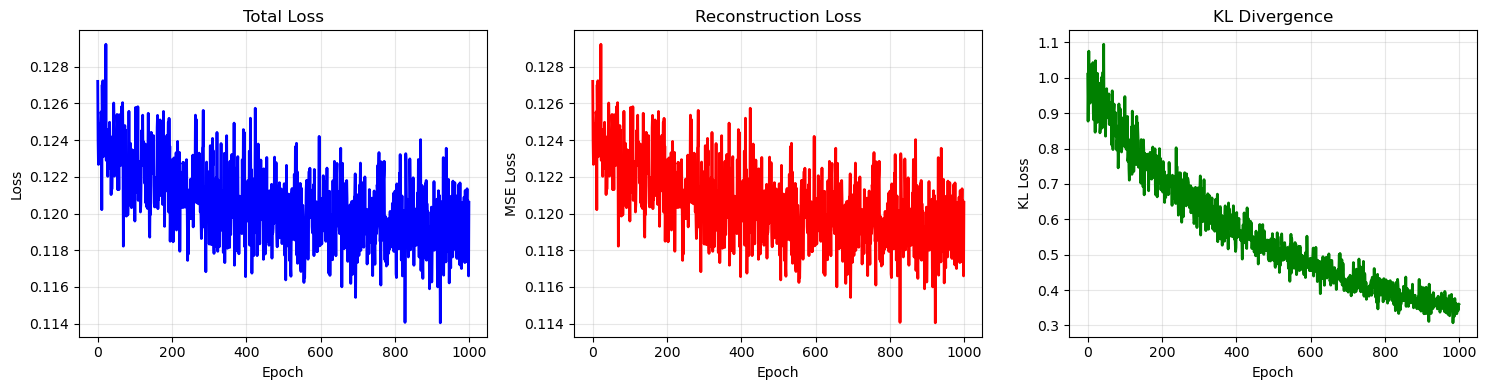


Training Summary:
Final losses - Total: 0.1206 | Recon: 0.1206 | KL: 0.3599
Best total loss: 0.1141 at epoch 922


In [15]:
def train_pointnet_vae():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")
    
    # Load dataset with DataLoader  
    dataset = PeptideDataset('./data/peptides', n_points=1024, max_files=10)
    dataloader = DataLoader(dataset, batch_size=10, shuffle=True, drop_last=True)
    #dataloader = [dataset[i].unsqueeze(0) for i in range(2)]
    
    model = PointNetPlusPlusVAE(latent_dim=512, num_points=1024).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-6, weight_decay=0)  # Remove weight decay for overfitting
    
    # Adjust BatchNorm for small batch training
    model.train()
    for module in model.modules():
        if isinstance(module, nn.BatchNorm2d) or isinstance(module, nn.BatchNorm1d):
            module.momentum = 0.5
    
    losses = []
    recon_losses = []
    kl_losses = []
    
    # Training loop with DataLoader and cyclic KL annealing
    for epoch in range(1000):
        epoch_loss = 0
        epoch_recon = 0
        epoch_kl = 0
        
        # Reduced KL weight for easier overfitting
        cycle_length = 10
        cycle_pos = (epoch % cycle_length) / cycle_length
        beta = 0.5 * (1 - np.cos(np.pi * cycle_pos))
        beta = 0 # disable KL 
        
        for batch_data in dataloader:
            batch_data = batch_data.to(device)
            
            optimizer.zero_grad()
            recon_batch, mu, logvar = model(batch_data)
            
            # Reconstruction + KL divergence loss with cyclic annealing
            recon_loss = F.mse_loss(recon_batch, batch_data, reduction='mean')
            kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
            total_loss = recon_loss + beta * kl_loss
            
            total_loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            epoch_loss += total_loss.item()
            epoch_recon += recon_loss.item()
            epoch_kl += kl_loss.item()
        
        avg_loss = epoch_loss / len(dataloader)
        avg_recon = epoch_recon / len(dataloader)
        avg_kl = epoch_kl / len(dataloader)
        
        losses.append(avg_loss)
        recon_losses.append(avg_recon)
        kl_losses.append(avg_kl)
        
        if epoch % 5 == 0:  # Print every 5 epochs for more detail
            print(f'Epoch {epoch:2d} | Total: {avg_loss:.4f} | Recon: {avg_recon:.4f} | KL: {avg_kl:.4f} | Beta: {beta:.5f}')
    
    # Plot training curves
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    # Total loss
    axes[0].plot(losses, 'b-', linewidth=2)
    axes[0].set_title('Total Loss', fontsize=12)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].grid(True, alpha=0.3)
    
    # Reconstruction loss
    axes[1].plot(recon_losses, 'r-', linewidth=2)
    axes[1].set_title('Reconstruction Loss', fontsize=12)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('MSE Loss')
    axes[1].grid(True, alpha=0.3)
    
    # KL divergence with cyclic annealing
    axes[2].plot(kl_losses, 'g-', linewidth=2, label='KL Loss')
    axes[2].set_title('KL Divergence', fontsize=12)
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('KL Loss')
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nTraining Summary:")
    print(f"Final losses - Total: {losses[-1]:.4f} | Recon: {recon_losses[-1]:.4f} | KL: {kl_losses[-1]:.4f}")
    print(f"Best total loss: {min(losses):.4f} at epoch {losses.index(min(losses))}")
    
    torch.save(model.state_dict(), 'pointnet_plus_plus_vae_peptide.pth')
    return model, losses, recon_losses, kl_losses

trained_model, total_losses, recon_losses, kl_losses = train_pointnet_vae()

In [16]:
# Test Trained Model - Shortest Code
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load model
model = PointNetPlusPlusVAE(latent_dim=512, num_points=1024).to(device)
checkpoint = torch.load('pointnet_plus_plus_vae.pth', weights_only=False)
model.load_state_dict(checkpoint)  
model.eval()

# Test with random input
with torch.no_grad():
    # Random point cloud input [batch=1, 3D coords, 1024 points]
    test_input = torch.randn(1, 3, 1024).to(device)
    
    # Forward pass
    reconstructed, mu, logvar = model(test_input)
    
    # Generate new sample from latent space - Fix latent dimension
    random_z = torch.randn(1, 512).to(device)  # Changed from 64 to 512 to match latent_dim
    generated = model.decoder(random_z)
    
    print(f"Model test successful!")
    print(f"Input shape: {test_input.shape}")
    print(f"Reconstructed shape: {reconstructed.shape}")
    print(f"Generated shape: {generated.shape}")
    print(f"Reconstruction MSE: {torch.nn.functional.mse_loss(reconstructed, test_input).item():.4f}")
    print(f"Latent dim: {mu.shape[1]}, mean: {mu.mean().item():.3f}, std: {mu.std().item():.3f}")

Model test successful!
Input shape: torch.Size([1, 3, 1024])
Reconstructed shape: torch.Size([1, 3, 1024])
Generated shape: torch.Size([1, 3, 1024])
Reconstruction MSE: 96.9155
Latent dim: 512, mean: 0.088, std: 7.448


In [5]:
# Visualize Real vs Reconstructed Point Cloud
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Load model and data
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = PointNetPlusPlusVAE(latent_dim=512, num_points=1024).to(device)
checkpoint = torch.load('pointnet_plus_plus_vae.pth', weights_only=False)
model.load_state_dict(checkpoint) 
model.eval()

# Get real ShapeNet sample
dataset = ShapeNetDataset('./data/PartAnnotation', n_points=1024, max_files=10)
real_pc = dataset[0].unsqueeze(0).to(device)  # [1, 3, 1024]

# Generate reconstruction
with torch.no_grad():
    recon_pc, mu, logvar = model(real_pc)

# Convert to numpy for visualization
real = real_pc.squeeze().cpu().numpy().T  # [1024, 3]
recon = recon_pc.squeeze().cpu().detach().numpy().T  # [1024, 3]

# Create side-by-side plot
fig = make_subplots(rows=1, cols=2, 
                    specs=[[{'type': 'scatter3d'}, {'type': 'scatter3d'}]],
                    subplot_titles=['Original Point Cloud', 'VAE Reconstruction'])

# Original point cloud
fig.add_trace(go.Scatter3d(x=real[:,0], y=real[:,1], z=real[:,2],
                          mode='markers', marker=dict(size=2, color='blue'),
                          name='Original'), row=1, col=1)

# Reconstructed point cloud  
fig.add_trace(go.Scatter3d(x=recon[:,0], y=recon[:,1], z=recon[:,2],
                          mode='markers', marker=dict(size=2, color='red'),
                          name='Reconstructed'), row=1, col=2)

fig.update_layout(height=500, width=1000, showlegend=False,
                 title_text="PointNet VAE: Original vs Reconstruction")
fig.show()

print(f"MSE: {F.mse_loss(recon_pc, real_pc).item():.6f}")
print(f"Latent: μ={mu.mean():.3f}, σ={mu.std():.3f}")

Using 10 ShapeNet point cloud files


MSE: 0.133755
Latent: μ=0.007, σ=0.608


In [4]:
# PointNet++ Encoder & FC Decoder Implementation
import torch
import torch.nn as nn
import torch.nn.functional as F

def knn(x, k):
    """Find k-nearest neighbors"""
    inner = -2*torch.matmul(x.transpose(2, 1), x)
    xx = torch.sum(x**2, dim=1, keepdim=True)
    pairwise_distance = -xx - inner - xx.transpose(2, 1)
    idx = pairwise_distance.topk(k=k, dim=-1)[1]   # (batch_size, num_points, k)
    return idx

def get_graph_feature(x, k=20, idx=None):
    """Build graph features for EdgeConv"""
    batch_size = x.size(0)
    num_points = x.size(2)
    x = x.view(batch_size, -1, num_points)
    if idx is None:
        idx = knn(x, k=k)   # (batch_size, num_points, k)
    device = torch.device('cuda')

    idx_base = torch.arange(0, batch_size, device=device).view(-1, 1, 1)*num_points
    idx = idx + idx_base
    idx = idx.view(-1)
 
    _, num_dims, _ = x.size()
    x = x.transpose(2, 1).contiguous()   # (batch_size, num_points, num_dims)
    feature = x.view(batch_size*num_points, -1)[idx, :]
    feature = feature.view(batch_size, num_points, k, num_dims) 
    x = x.view(batch_size, num_points, 1, num_dims).repeat(1, 1, k, 1)
    
    feature = torch.cat((feature-x, x), dim=3).permute(0, 3, 1, 2).contiguous()
    return feature

class PointNetPlusPlusEncoder(nn.Module):
    """PointNet++ style encoder with set abstraction"""
    def __init__(self, latent_dim=128):
        super().__init__()
        # EdgeConv layers for local feature learning
        self.conv1 = nn.Conv2d(6, 64, kernel_size=1, bias=False)
        self.conv2 = nn.Conv2d(128, 128, kernel_size=1, bias=False)
        self.conv3 = nn.Conv2d(256, 256, kernel_size=1, bias=False)
        
        self.bn1 = nn.BatchNorm2d(64)
        self.bn2 = nn.BatchNorm2d(128)
        self.bn3 = nn.BatchNorm2d(256)
        
        # Global feature aggregation
        self.conv4 = nn.Conv1d(448, 512, kernel_size=1, bias=False)
        self.bn4 = nn.BatchNorm1d(512)
        
        # Final encoding to latent space
        self.fc1 = nn.Linear(512, 256)
        self.fc_mu = nn.Linear(256, latent_dim)
        self.fc_logvar = nn.Linear(256, latent_dim)
        self.dropout = nn.Dropout(0.5)
        
    def forward(self, x):
        # x: (batch, 3, num_points)
        batch_size = x.size(0)
        
        # Layer 1
        x1 = get_graph_feature(x, k=20)      # (batch, 6, num_points, k)
        x1 = F.relu(self.bn1(self.conv1(x1)))  # (batch, 64, num_points, k)
        x1 = x1.max(dim=-1, keepdim=False)[0]  # (batch, 64, num_points)

        # Layer 2
        x2 = get_graph_feature(x1, k=20)     # (batch, 128, num_points, k)
        x2 = F.relu(self.bn2(self.conv2(x2)))  # (batch, 128, num_points, k)
        x2 = x2.max(dim=-1, keepdim=False)[0]  # (batch, 128, num_points)

        # Layer 3
        x3 = get_graph_feature(x2, k=20)     # (batch, 256, num_points, k)
        x3 = F.relu(self.bn3(self.conv3(x3)))  # (batch, 256, num_points, k)
        x3 = x3.max(dim=-1, keepdim=False)[0]  # (batch, 256, num_points)

        # Concatenate multi-scale features
        x = torch.cat((x1, x2, x3), dim=1)   # (batch, 448, num_points)
        
        # Global aggregation
        x = F.relu(self.bn4(self.conv4(x)))   # (batch, 512, num_points)
        x = F.adaptive_max_pool1d(x, 1).view(batch_size, -1)  # (batch, 512)
        
        # Encode to latent space
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        
        return mu, logvar

class FCDecoder(nn.Module):
    """Fully Connected Decoder for point cloud generation"""
    def __init__(self, latent_dim=128, num_points=1024):
        super().__init__()
        self.num_points = num_points
        
        self.fc1 = nn.Linear(latent_dim, 256)
        self.fc2 = nn.Linear(256, 512)
        self.fc3 = nn.Linear(512, 1024)
        self.fc4 = nn.Linear(1024, num_points * 3)  # Output 3D coordinates
        
        self.dropout = nn.Dropout(0.2)
        
    def forward(self, z):
        # z: (batch, latent_dim)
        x = F.relu(self.fc1(z))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = F.relu(self.fc3(x))
        x = self.fc4(x)
        
        # Reshape to point cloud: (batch, 3, num_points)
        x = x.view(-1, 3, self.num_points)
        return x

class PointNetPlusPlusVAE(nn.Module):
    """Complete PointNet++ VAE"""
    def __init__(self, latent_dim=128, num_points=1024):
        super().__init__()
        self.encoder = PointNetPlusPlusEncoder(latent_dim)
        self.decoder = FCDecoder(latent_dim, num_points)
        
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decoder(z)
        return recon, mu, logvar

# Test the models
print("🔥 PointNet++ VAE Implementation Complete!")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Create model
model = PointNetPlusPlusVAE(latent_dim=128, num_points=1024).to(device)

# Test with random input
test_input = torch.randn(2, 3, 1024).to(device)
recon, mu, logvar = model(test_input)


🔥 PointNet++ VAE Implementation Complete!
✅ Model test successful!
Input shape: torch.Size([2, 3, 1024])
Reconstruction shape: torch.Size([2, 3, 1024])
Latent mu shape: torch.Size([2, 128])
Latent logvar shape: torch.Size([2, 128])
Total parameters: 4,349,440


In [10]:
# Plot Training Loss Curves from Saved Checkpoint
import torch
import matplotlib.pyplot as plt

# Load the checkpoint
checkpoint = torch.load('pointnet_plus_plus_vae_peptide.pth', map_location='cpu')

# Extract saved losses
losses = checkpoint['losses']
recon_losses = checkpoint['recon_losses'] 
kl_losses = checkpoint['kl_losses']

# Create loss plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Total loss
axes[0].plot(losses, 'b-', linewidth=2)
axes[0].set_title('Total Loss', fontsize=12)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True, alpha=0.3)

# Reconstruction loss
axes[1].plot(recon_losses, 'r-', linewidth=2)
axes[1].set_title('Reconstruction Loss', fontsize=12)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MSE Loss')
axes[1].grid(True, alpha=0.3)

# KL divergence
axes[2].plot(kl_losses, 'g-', linewidth=2)
axes[2].set_title('KL Divergence', fontsize=12)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('KL Loss')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print final statistics
print(f"Training completed after {len(losses)} epochs")
print(f"Final total loss: {losses[-1]:.4f}")
print(f"Final reconstruction loss: {recon_losses[-1]:.4f}")
print(f"Final KL loss: {kl_losses[-1]:.4f}")
print(f"Best total loss: {min(losses):.4f} at epoch {losses.index(min(losses))}")

/tmp/ipykernel_2145551/1642443518.py:6: FutureWarning:

You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.



KeyError: 'losses'